In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import files
files.upload()   # chọn kaggle.json upload

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hunhsnguyn","key":"333befdc0d26fdedd24f481e915311cc"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [11]:
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition -p /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/


Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
fruit-and-vegetable-image-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)


In [12]:
!kaggle datasets list


ref                                                               title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                                          Heart Disease                                            3491  2025-12-11 15:29:14.327000           2114        289  1.0              
rockyt07/social-media-user-analysis                               Social Media User Analysis                          247842357  2026-01-14 02:28:41.970000              0         63  1.0              
neurocipher/student-performance                                   Student Performance                                     49705  2025-12-12 12:06:28.973000           1261        164  1.0          

In [13]:
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition


Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
 99% 1.96G/1.98G [00:21<00:00, 156MB/s]
100% 1.98G/1.98G [00:21<00:00, 97.4MB/s]


In [ ]:
!unzip /content/fruit-and-vegetable-image-recognition.zip -d /content/fruit-and-vegetable-image-recognition


# Import thư viện cần thiết

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import seaborn as sns
import shutil

In [23]:
np.random.seed(42)
tf.random.set_seed(42)

In [24]:

local_dataset_path = '/content/fruit-and-vegetable-image-recognition'
drive_path = local_dataset_path

In [25]:
data_path = Path(f'{drive_path}/train')

class_folders = sorted([f for f in data_path.iterdir() if f.is_dir()])
print(f"Số lượng loại: {len(class_folders)}")

Số lượng loại: 36


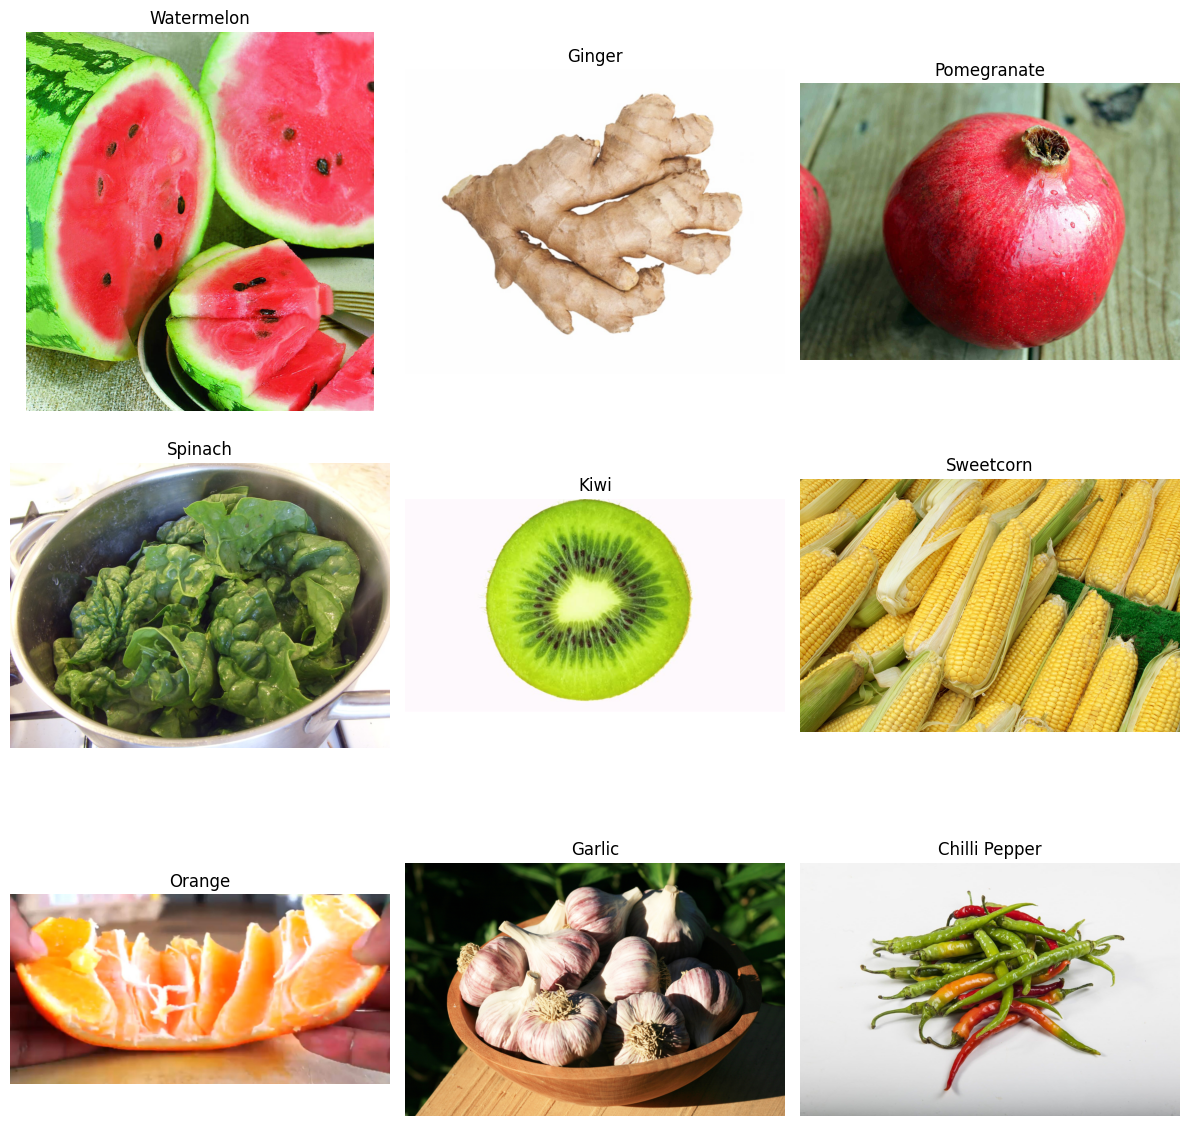

In [26]:
# Hiển thị một số ảnh mẫu
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()
for idx, folder in enumerate(np.random.choice(class_folders, 9, replace=False)):
    imgs = list(folder.glob('*.jpg'))
    if imgs:
        img = Image.open(np.random.choice(imgs))
        axes[idx].imshow(img)
        axes[idx].set_title(folder.name.replace('_', ' ').title())
        axes[idx].axis('off')
plt.tight_layout()
plt.show()

# Tiền xử lý dữ liệu

In [27]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 36

In [37]:
# Data augmentation cho training set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    f'{drive_path}/train', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
print(f"Số lượng mẫu cho train: {train_gen.samples}")

Found 3115 images belonging to 36 classes.
Số lượng mẫu cho train: 3115


In [39]:
# Chỉ rescale cho validation set
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = val_datagen.flow_from_directory(
    f'{drive_path}/validation', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=42
)
print(f"Số lượng mẫu cho validate: {val_gen.samples}")

Found 351 images belonging to 36 classes.
Số lượng mẫu cho validate: 351


In [40]:
#Tạo test generator tương tự validation
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    f'{drive_path}/test', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=42
)
print(f"Số lượng mẫu cho test: {test_gen.samples}")

Found 359 images belonging to 36 classes.
Số lượng mẫu cho test: 359


# Huấn luyện: MobileNetV2

In [41]:
base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

In [42]:
model_path = "/content/drive/MyDrive/Thuc_tap_tot_nghiep/ML_models"

In [43]:
model = Model(inputs=base_model.input, outputs=predictions)

In [44]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
# Callbacks
callbacks = [
    ModelCheckpoint(f'{model_path}/stage1_mobilenet.h5', monitor='val_accuracy',
                    save_best_only=True, mode='max'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

In [47]:
# Train Stage 1
history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8073 - loss: 0.5941

49/49 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.8072 - loss: 0.5945 - val_accuracy: 0.9174 - val_loss: 0.2546 - learning_rate: 0.0010
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8079 - loss: 0.5560

49/49 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.8082 - loss: 0.5555 - val_accuracy: 0.9430 - val_loss: 0.2157 - learning_rate: 0.0010
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.8426 - loss: 0.4663 - val_accuracy: 0.9202 - val_loss: 0.2249 - learning_rate: 0.0010
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.8542 - loss: 0.4238 - val_accuracy: 0.9259 - val_loss: 0.2157 - learning_rate: 0.0010
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8725 - loss: 0.3947 - val_accuracy: 0.9231 - val_loss: 0.2051 - learning_rate: 0.0010
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8847 - loss: 0.3532 - val_accuracy: 0.9288 - val_loss: 0.2134 - learning_rate: 0.0010
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.8852 - loss: 0.3465 - val_accuracy: 0.9430 - val_loss: 0.1943 - learning_rate: 0.0010
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8846 - loss: 0.3228

49/49 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.8846 - loss: 0.3227 - val_accuracy: 0.9487 - val_loss: 0.1852 - learning_rate: 0.0010
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8945 - loss: 0.3111 - val_accuracy: 0.9487 - val_loss: 0.1684 - learning_rate: 0.0010
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9065 - loss: 0.2767

49/49 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9064 - loss: 0.2770 - val_accuracy: 0.9544 - val_loss: 0.1850 - learning_rate: 0.0010


In [48]:
model.save(f'{model_path}/mobilenet_v2_stage1.h5')

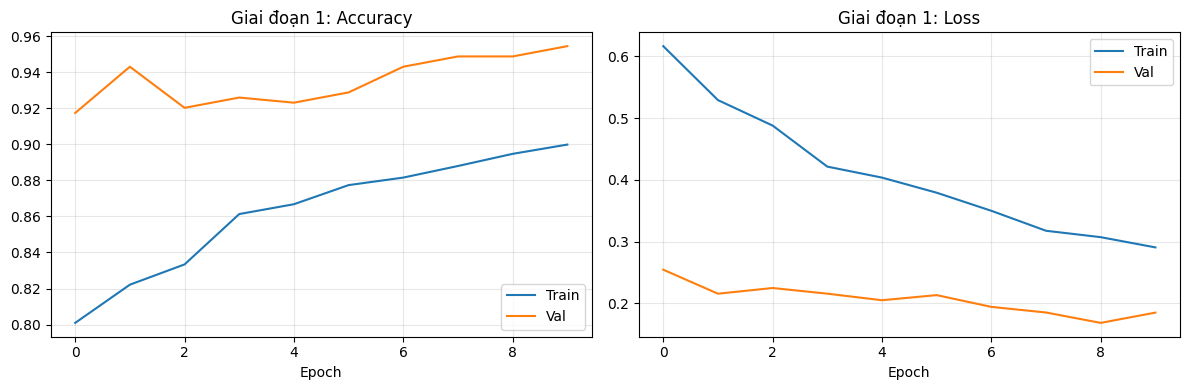

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history1.history['accuracy'], label='Train')
ax1.plot(history1.history['val_accuracy'], label='Val')
ax1.set_title('Giai đoạn 1: Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history1.history['loss'], label='Train')
ax2.plot(history1.history['val_loss'], label='Val')
ax2.set_title('Giai đoạn 1: Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Unfreeze
model.load_weights(f"{model_path}/stage1_mobilenet.h5")
base_model.trainable = True

In [51]:
# Chỉ train 30 layers cuối
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [52]:
# Compile với learning rate nhỏ hơn 10 lần
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
callbacks2 = [
    ModelCheckpoint(f"{model_path}/stage2_mobilenet.h5", monitor='val_accuracy',
                    save_best_only=True, mode='max'),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8)
]

In [55]:
history2 = model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    callbacks=callbacks2
)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8041 - loss: 0.6369

49/49 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8048 - loss: 0.6344 - val_accuracy: 0.8832 - val_loss: 0.3090 - learning_rate: 1.0000e-04
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8779 - loss: 0.3301

49/49 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8781 - loss: 0.3296 - val_accuracy: 0.9003 - val_loss: 0.2965 - learning_rate: 1.0000e-04
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9052 - loss: 0.2609

49/49 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9052 - loss: 0.2609 - val_accuracy: 0.9031 - val_loss: 0.2512 - learning_rate: 1.0000e-04
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9347 - loss: 0.1875

49/49 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9346 - loss: 0.1878 - val_accuracy: 0.9316 - val_loss: 0.2381 - learning_rate: 1.0000e-04
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.9249 - loss: 0.2004 - val_accuracy: 0.9316 - val_loss: 0.2266 - learning_rate: 1.0000e-04


In [56]:
model.save(f"{model_path}/final_model_mobilenet.h5")

# Đánh giá mô hình

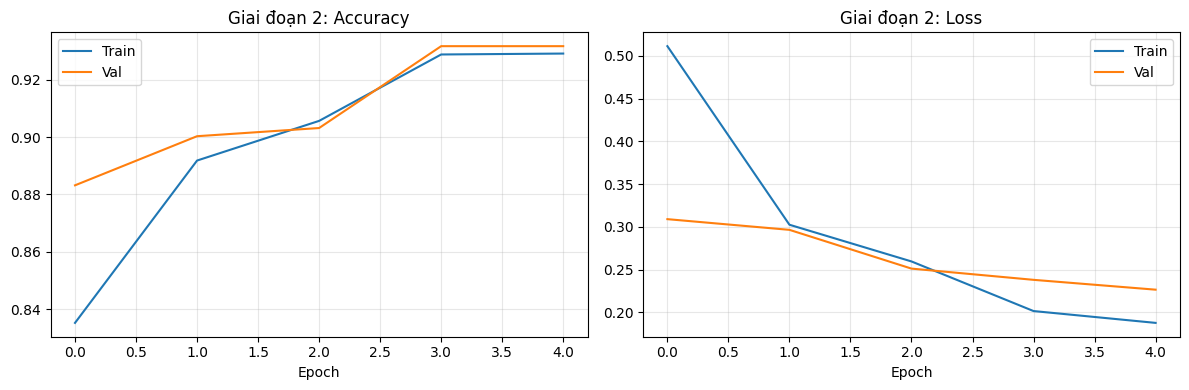

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history2.history['accuracy'], label='Train')
ax1.plot(history2.history['val_accuracy'], label='Val')
ax1.set_title('Giai đoạn 2: Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history2.history['loss'], label='Train')
ax2.plot(history2.history['val_loss'], label='Val')
ax2.set_title('Giai đoạn 2: Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Load model tốt nhất
model.load_weights(f"{model_path}/stage2_mobilenet.h5")

In [63]:
# Đánh giá trên tập test
test_results = model.evaluate(test_gen)
print(f"Độ chính xác trên tập test : {test_results[1]*100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.9185 - loss: 0.3129
Độ chính xác trên tập test : 93.31%


In [64]:
# Dự đoán trên tập test
test_gen.reset()
y_test_pred = model.predict(test_gen, steps=len(test_gen))
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true = test_gen.classes[:len(y_test_pred_classes)]

6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step


In [65]:
print("\nBáo cáo phân loại :")
class_names = list(test_gen.class_indices.keys())
print(classification_report(y_test_true, y_test_pred_classes,
                            target_names=[n.replace('_',' ').title() for n in class_names]))


Báo cáo phân loại :
               precision    recall  f1-score   support

        Apple       0.75      0.90      0.82        10
       Banana       1.00      0.78      0.88         9
     Beetroot       1.00      1.00      1.00        10
  Bell Pepper       0.75      0.90      0.82        10
      Cabbage       1.00      1.00      1.00        10
     Capsicum       0.75      0.90      0.82        10
       Carrot       1.00      0.90      0.95        10
  Cauliflower       1.00      1.00      1.00        10
Chilli Pepper       0.82      0.90      0.86        10
         Corn       1.00      0.20      0.33        10
     Cucumber       1.00      1.00      1.00        10
     Eggplant       1.00      1.00      1.00        10
       Garlic       1.00      1.00      1.00        10
       Ginger       1.00      1.00      1.00        10
       Grapes       1.00      1.00      1.00        10
     Jalepeno       1.00      0.90      0.95        10
         Kiwi       1.00      1.00      1.0

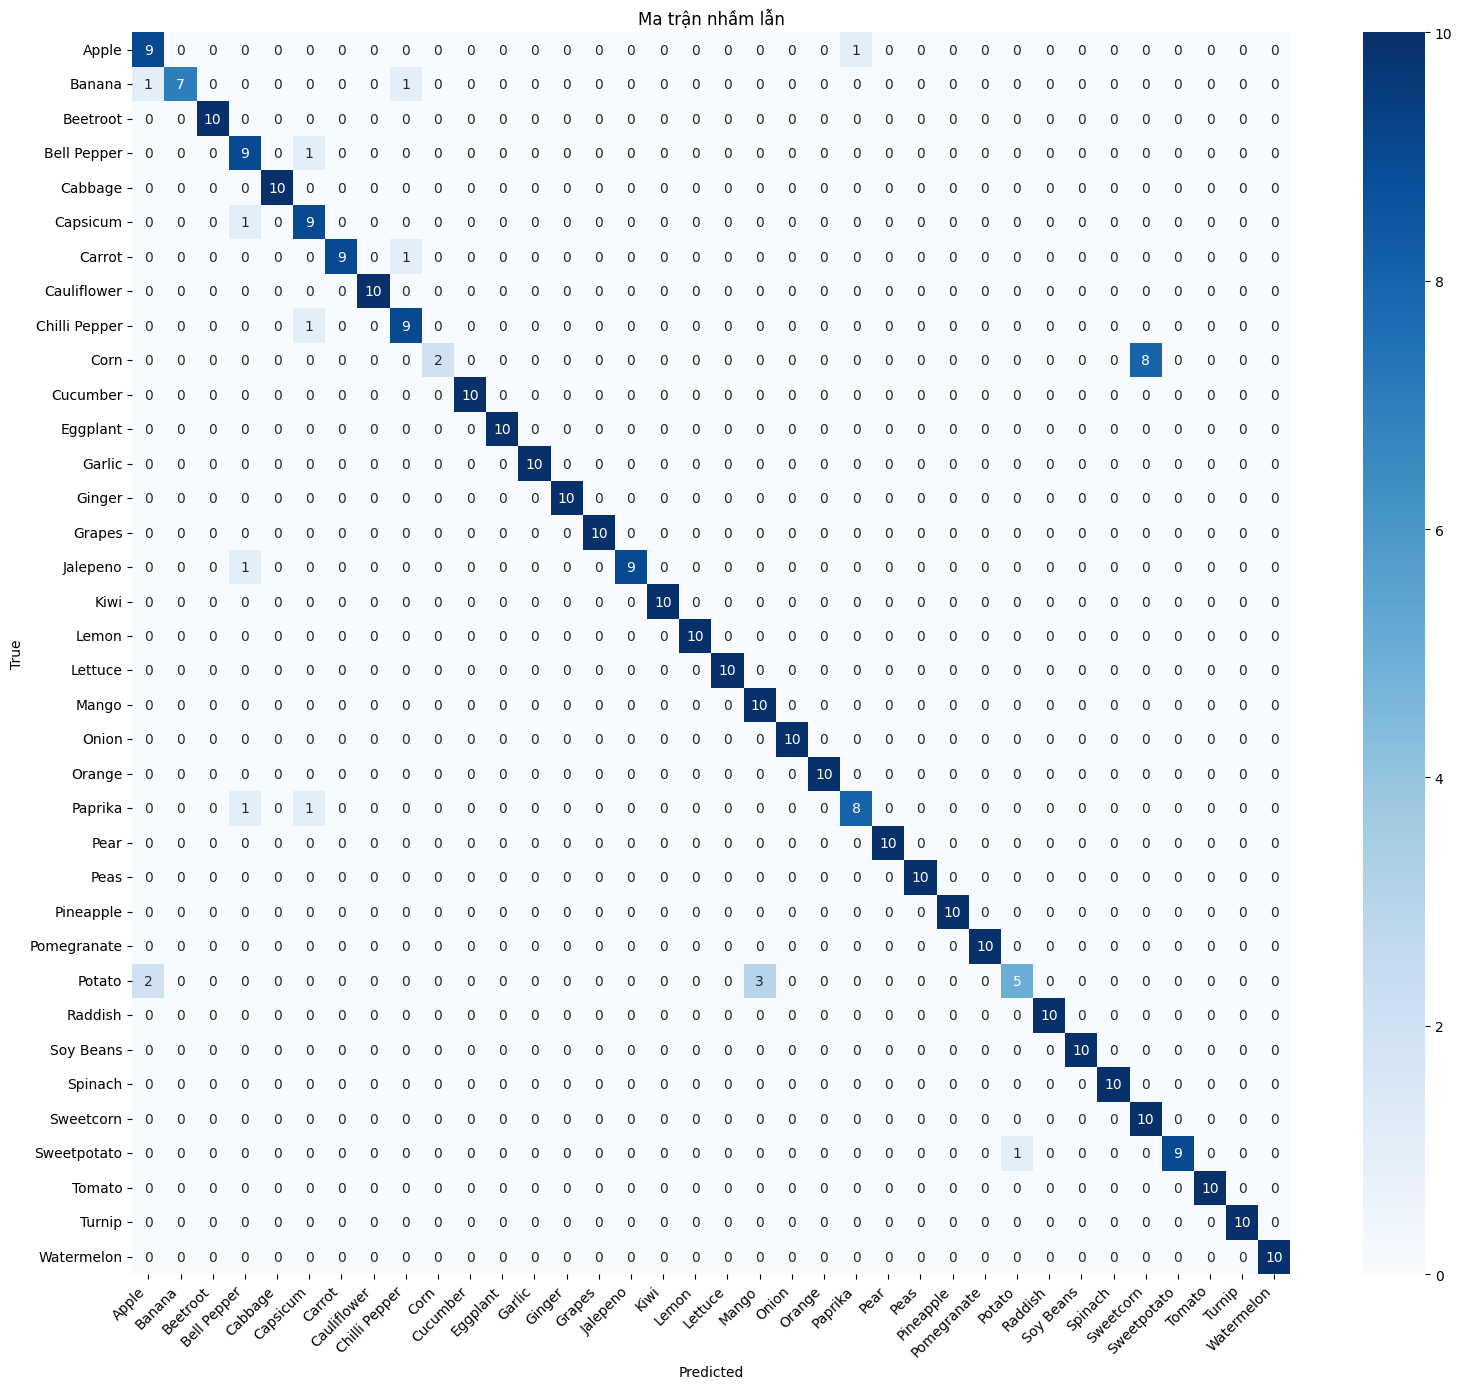

In [66]:
cm_test = confusion_matrix(y_test_true, y_test_pred_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=[n.replace('_',' ').title() for n in class_names],
            yticklabels=[n.replace('_',' ').title() for n in class_names])
plt.title('Ma trận nhầm lẫn')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [67]:
results = model.evaluate(val_gen)
print(f"Độ chính xác trên tập val: {results[1]*100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9177 - loss: 0.3127
Độ chính xác trên tập val: 93.16%


In [68]:
val_gen.reset()
y_pred = model.predict(val_gen, steps=len(val_gen))
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes[:len(y_pred_classes)]

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step


In [69]:
print("\n Báo cáo phân loại :")
print(classification_report(y_true, y_pred_classes,
                            target_names=[n.replace('_',' ').title() for n in class_names]))


 Báo cáo phân loại :
               precision    recall  f1-score   support

        Apple       0.75      0.90      0.82        10
       Banana       1.00      0.78      0.88         9
     Beetroot       1.00      1.00      1.00        10
  Bell Pepper       0.73      0.89      0.80         9
      Cabbage       1.00      1.00      1.00        10
     Capsicum       0.75      0.90      0.82        10
       Carrot       1.00      0.89      0.94         9
  Cauliflower       1.00      1.00      1.00        10
Chilli Pepper       0.80      0.89      0.84         9
         Corn       1.00      0.20      0.33        10
     Cucumber       1.00      1.00      1.00        10
     Eggplant       1.00      1.00      1.00        10
       Garlic       1.00      1.00      1.00        10
       Ginger       1.00      1.00      1.00        10
       Grapes       1.00      1.00      1.00         9
     Jalepeno       1.00      0.89      0.94         9
         Kiwi       1.00      1.00      1.

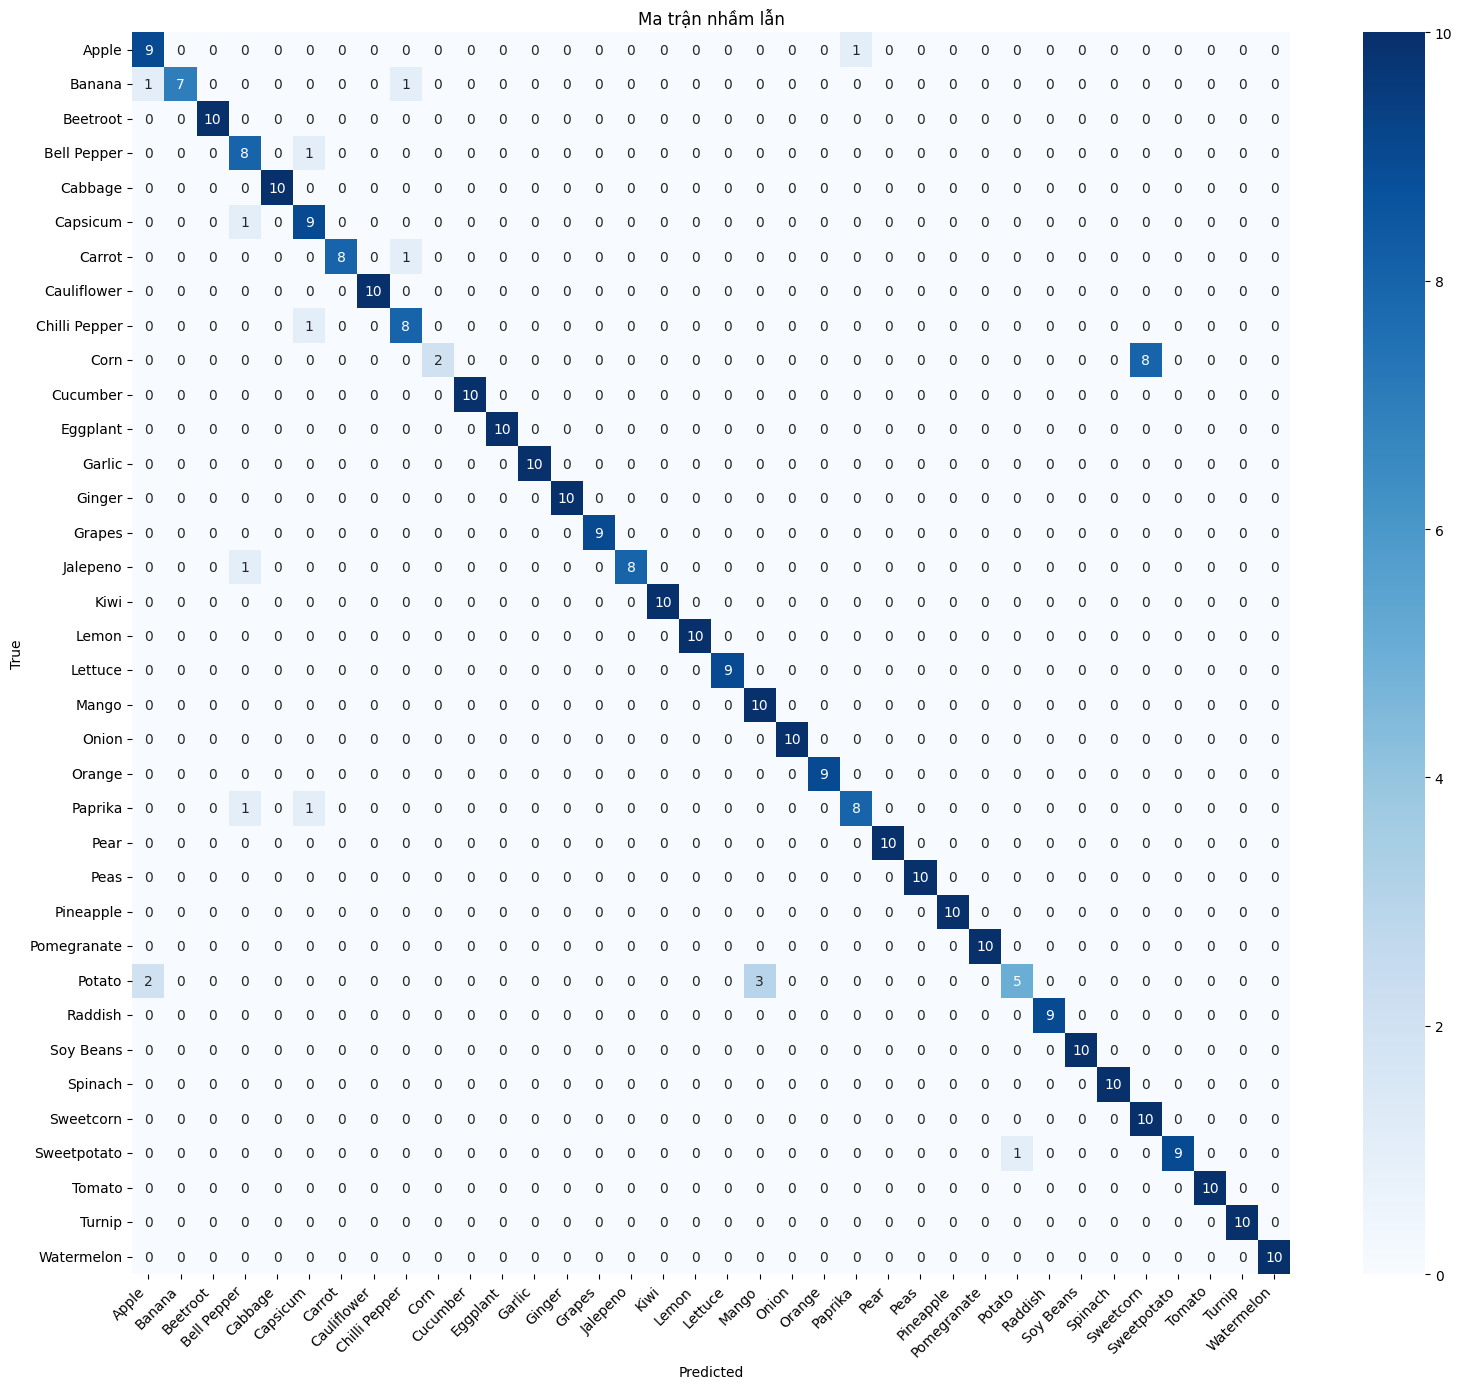

In [70]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[n.replace('_',' ').title() for n in class_names],
            yticklabels=[n.replace('_',' ').title() for n in class_names])
plt.title('Ma trận nhầm lẫn')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Tìm các cặp dễ nhầm lẫn nhất
confused_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > 0:
            confused_pairs.append((class_names[i], class_names[j], cm[i][j]))
confused_pairs.sort(key=lambda x: x[2], reverse=True)
print("Top 10 cặp dễ nhầm lẫn:")
for true_cls, pred_cls, count in confused_pairs[:10]:
    print(f"{true_cls.replace('_',' ').title()} → {pred_cls.replace('_',' ').title()}: {count}")

Top 10 cặp dễ nhầm lẫn:
Corn → Sweetcorn: 8
Potato → Mango: 3
Potato → Apple: 2
Apple → Paprika: 1
Banana → Apple: 1
Banana → Chilli Pepper: 1
Bell Pepper → Capsicum: 1
Capsicum → Bell Pepper: 1
Carrot → Chilli Pepper: 1
Chilli Pepper → Capsicum: 1


In [73]:
class_names = list(train_gen.class_indices.keys())
print(class_names)

['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
